# Análise Topológica de Dados - SME0231 - Trabalho 1
Ana Beatriz Araujo Ferreira - 12678044

Tulio

Bruna



In [1]:
pip install gudhi

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import gudhi as gd  
import matplotlib as mpl
import sklearn as skl


### Reproduction of the first example from the paper
Here we reproduce the first example of the topological methods from "ref paper", but adding a third generated point cloud of a different shape.


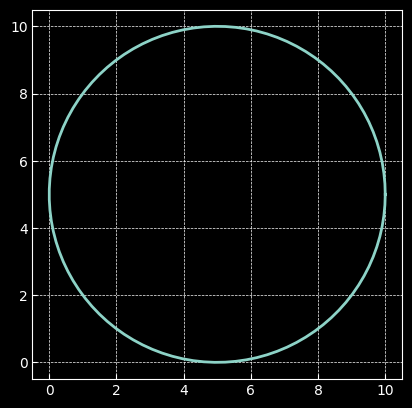

In [96]:
### Making the point clouds and plotting them
from matplotlib import colormaps
#from colorspacious import cspace_converter
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

#mpl.style.use('bmh')

pnt_cloud_circle = np.random.default_rng(42).random((150,150))

x_center, y_center = 5, 5
radius = 5

# generating linspace angles
angles = np.linspace(0, 2*np.pi, 100)
x = x_center + radius * np.cos(angles)
y = y_center + radius * np.sin(angles)


fig,ax = plt.subplots()
ax.set_aspect('equal')
ax.plot(x, y, linewidth=2)
plt.show()




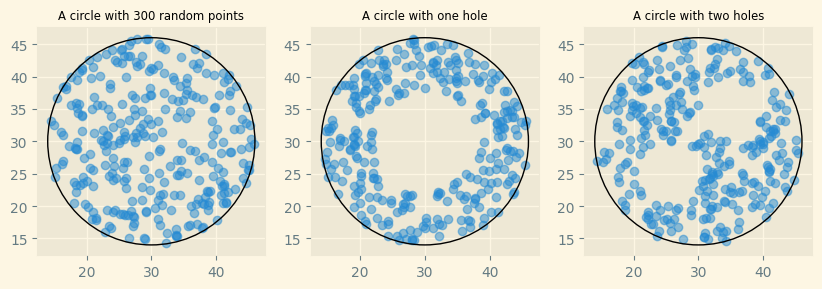

In [107]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('Solarize_Light2')

def notInsideMask(function):
    # for f closed, 
    # f > 0 outside of function
    # f = 0 on function line
    # f < 0 inside function
    if(function > 0):
        return True
    else:
        return False


def circle(x, y, a, b, r):
    return (x - a)**2 + (y - b)**2 - r**2


def make_points_circle(x_center : float, y_center : float, radius : float, n : int) -> tuple[list[float],  list[float]]:
    """
    make_points_circle. Returns two arrays of size n with the x coordinates and y coordinates of the points.
    
    Args:
        x_center: x position of center
        y_center: y position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_circle(x_center="0", y_center="0", radius="100", n="50")
    """
    rng = np.random.default_rng(seed=42)
    x_points, y_points = [],[]
    

    while ((len(x_points) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        u = np.random.uniform(0, 1, 1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.sqrt(u) * np.cos(theta)
        batch_y = y_center + radius * np.sqrt(u) * np.sin(theta)

        x_points.append(batch_x)
        y_points.append(batch_y)

    return x_points, y_points


def make_points_circle_w_hole(x_center : float, y_center : float, radius : float, n : int) -> tuple[list[float],  list[float]]:
    """
    make_points_circle_w_hole. Returns two arrays of size n with the x coordinates and y coordinates of the points. 
    
    Args:
        x_center: x position of center
        y_center: y position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_circle_w_hole(x_center="0", y_center="0", radius="100", n="50")
    """
    rng = np.random.default_rng(seed=42)
    x, y = [],[]
    
    inner_r = radius * 0.5
    offset = radius * 0.3

    while ((len(x) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        u = np.random.uniform(0, 1, 1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.sqrt(u) * np.cos(theta)
        batch_y = y_center + radius * np.sqrt(u) * np.sin(theta)

        if(notInsideMask(circle(batch_x, batch_y, x_center, y_center, inner_r))):    
            x.append(batch_x)
            y.append(batch_y)
        
    return x, y


def make_points_circle_w_two_holes(x_center : float, y_center : float, radius : float, n : int) -> tuple[list[float],  list[float]]:
    """
    make_points_circle_w_hole. Returns two arrays of size n with the x coordinates and y coordinates of the points. 
    
    Args:
        x_center: x position of center
        y_center: y position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_circle_w_hole(x_center="0", y_center="0", radius="100", n="50")
    """
    rng = np.random.default_rng(seed=42)
    x, y = [],[]
    
    inner_r = radius * 0.3
    offset = radius * 0.3

    while ((len(x) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        u = np.random.uniform(0, 1, 1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.sqrt(u) * np.cos(theta)
        batch_y = y_center + radius * np.sqrt(u) * np.sin(theta)

        if(notInsideMask(circle(batch_x, batch_y, x_center - offset, y_center - offset, inner_r))): 
            if(notInsideMask(circle(batch_x, batch_y, x_center + offset, y_center + offset, inner_r))):   
                x.append(batch_x)
                y.append(batch_y)
            
    return x, y



rng = np.random.default_rng(seed=42)

max_n_points = 300
x_center, y_center = 30, 30
outer_radius = 16
inner_radius = 8


def plot_circle(x : list[float], y : list[float], ax : 'Axes'):
    ax.scatter(x, y, linewidths=1, alpha=0.5)
    ax.add_patch(plt.Circle((x_center,y_center),outer_radius,fill=False))
    ax.set_aspect('equal')

    return ax


fig,axs = plt.subplots(ncols=3, figsize=(10,18))


x_0, y_0 = make_points_circle(x_center, y_center, 16, 300)
axs[0] = plot_circle(x_0, y_0, axs[0])
axs[0].set_title('A circle with %i random points' % max_n_points, {'fontsize': 'small'})


x_1, y_1 = make_points_circle_w_hole(x_center, y_center, 16, 300)
axs[1] = plot_circle(x_1, y_1, axs[1])
axs[1].set_title('A circle with one hole', {'fontsize': 'small'})

x_2, y_2 = make_points_circle_w_two_holes(x_center,y_center,16, 300)
axs[2] = plot_circle(x_2, y_2, axs[2])
axs[2].set_title('A circle with two holes', {'fontsize': 'small'})
plt.show()



AttributeError: 'list' object has no attribute 'rows'

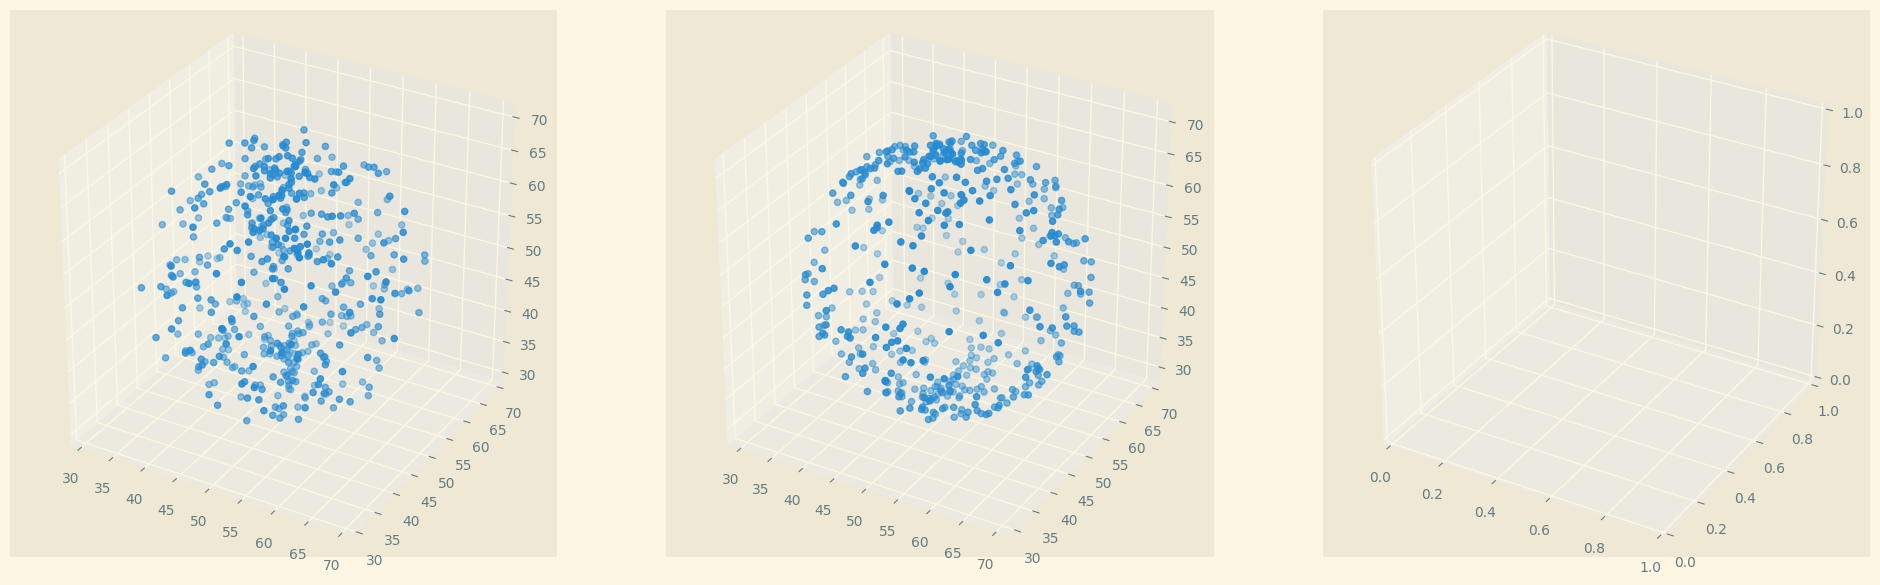

In [ ]:


from matplotlib import animation
from mpl_toolkits.mplot3d import axes3d

def make_points_sphere(x_center : float, y_center : float, z_center, radius : float, n : int) -> list[list[float],  list[float], list[float]]:
    """
    make_points_sphere. Returns three arrays of size n with the x, y and z coordinates of the points.
    
    Args:
        x_center: x position of center
        y_center: y position of center
        z_center: z position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_sphere(x_center=0, y_center=0, z_center=0, radius=100, n=50)
    """
    rng = np.random.default_rng(seed=42)
    x_points, y_points, z_points = [],[], []
    coords =[x_points, y_points, z_points]

    while ((len(x_points) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        omega = np.random.uniform(0, 2 * np.pi, batch_size)
        
        u = np.random.uniform(0, 1, 1)
        v = np.random.uniform(0,1,1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.cbrt(u) * np.cos(theta) * np.cos(omega) 
        batch_y = y_center + radius * np.cbrt(u) * np.sin(theta) * np.cos(omega) 
        batch_z = z_center + radius * np.cbrt(u) * np.sin(omega) 

        x_points.append(batch_x)
        y_points.append(batch_y)
        z_points.append(batch_z)

    return coords

def sphere(x, y, z, a, b, c, r):
    return (x - a)**2 + (y - b)**2 + (z - c)**2 - r**2

def make_points_sphere_w_hole(x_center : float, y_center : float, z_center, radius : float, n : int) -> list[list[float],  list[float], list[float]]:
    """
    make_points_sphere. Returns three arrays of size n with the x, y and z coordinates of the points.
    
    Args:
        x_center: x position of center
        y_center: y position of center
        z_center: z position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_sphere(x_center=0, y_center=0, z_center=0, radius=100, n=50)
    """
    rng = np.random.default_rng(seed=42)
    x_points, y_points, z_points = [],[], []
    coords =[x_points, y_points, z_points]
    
    inner_r = radius * 0.9
    while ((len(x_points) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        omega = np.random.uniform(0, 2 * np.pi, batch_size)
        
        u = np.random.uniform(0, 1, 1)
        v = np.random.uniform(0,1,1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.cbrt(u) * np.cos(theta) * np.cos(omega) 
        batch_y = y_center + radius * np.cbrt(u) * np.sin(theta) * np.cos(omega) 
        batch_z = z_center + radius * np.cbrt(u) * np.sin(omega) 

        if(notInsideMask(sphere(batch_x, batch_y, batch_z, x_center, y_center, z_center, inner_r))):
            x_points.append(batch_x)
            y_points.append(batch_y)
            z_points.append(batch_z)

    return coords

def make_points_sphere_w_two_holes(x_center : float, y_center : float, z_center, radius : float, n : int) -> list[list[float],  list[float], list[float]]:
    """
    make_points_sphere. Returns three arrays of size n with the x, y and z coordinates of the points.
    
    Args:
        x_center: x position of center
        y_center: y position of center
        z_center: z position of center
        radius: circle size
        n: number of points
    
    Example:
        >>> make_points_sphere(x_center=0, y_center=0, z_center=0, radius=100, n=50)
    """
    rng = np.random.default_rng(seed=42)
    x_points, y_points, z_points = [],[], []
    coords =[x_points, y_points, z_points]
    
    inner_r = radius * 0.3
    offset = radius * 0.3
    while ((len(x_points) < n)):
        batch_size = 1
        theta = np.random.uniform(0, 2 * np.pi, batch_size)
        omega = np.random.uniform(0, 2 * np.pi, batch_size)
        
        u = np.random.uniform(0, 1, 1)
        v = np.random.uniform(0,1,1)
        # sqrt trick makes sure uniform distribution from center to edges of circle
        batch_x = x_center + radius * np.cbrt(u) * np.cos(theta) * np.cos(omega) 
        batch_y = y_center + radius * np.cbrt(u) * np.sin(theta) * np.cos(omega) 
        batch_z = z_center + radius * np.cbrt(u) * np.sin(omega) 

        if(notInsideMask(sphere(batch_x, batch_y, batch_z, x_center - offset, y_center - offset, z_center - offset, inner_r))):
            if(notInsideMask(sphere(batch_x, batch_y, batch_z, x_center + offset, y_center + offset , z_center + offset, inner_r))):
                x_points.append(batch_x)
                y_points.append(batch_y)
                z_points.append(batch_z)

    return coords


fig = plt.figure(figsize=(24,8))
ax = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sphere_coords = make_points_sphere(50, 50, 50, 20, 500)

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = 50 +20 * np.outer(np.cos(u), np.sin(v))
y = 50 + 20 * np.outer(np.sin(u), np.sin(v))
z = 50 + 20 * np.outer(np.ones(np.size(u)), np.cos(v))
#ax.plot_surface(x, y, z, alpha=0.1, color='green')
ax.set_aspect('equal')

ax.scatter(sphere_coords[0], sphere_coords[1], sphere_coords[2])

sphere2_coords = make_points_sphere_w_hole(50, 50, 50, 20, 500)
ax2.set_aspect('equal')
ax2.scatter(sphere2_coords[0], sphere2_coords[1], sphere2_coords[2])

sphere3_coords = make_points_sphere_w_hole(50, 50, 50, 20, 500)
ax3.set_aspect('equal')

r = np.array([50,50,50])
all_points = []
point = np.zeros((1,3))
distances = np.zeros((1, 500))
for n in range(0,500):
    point = sphere3_coords
    dist = np.linalg.norm(point - r) 
    print(dist)
    distances[n] = dist 
    #dist = np.linalg.norm(point - r)
    #distances[n] = dist

ax3.scatter(sphere3_coords[0], sphere3_coords[1], sphere3_coords[2], cmap="coolwarm", c=distances)


plt.show()
